# ДЗ 3. Дообучение BERT для распознавания именованных сущностей (NER)

---

### Зачем это нужно

Извлечение именованных сущностей (Named Entity Recognition, NER) —  людей, организаций, географических объектов и других сущностей —  это один из первых шагов превращения неструктурированного текста в структурированные данные. На этой задаче строится поиск по сущностям, аналитика, извлечение информации и базы знаний.

Мы разобрали, как предобученную модель BERT можно адаптировать к новой задаче, заменив выходную классификационную голову и дообучив модель на размеченных данных. В этом домашнем задании вы проделаете этот процесс самостоятельно: возьмете предобученный русскоязычный BERT и дообучите его для задачи разметки последовательностей.

Главный результат работы —  не достижение высоких значений метрики, а корректная и осмысленная оценка качества модели. Вы увидите, почему в NER оценки на уровне токенов могут вводить в заблуждение, научитесь интерпретировать метрики на уровне сущностей и анализировать типичные ошибки модели.

### Что вы сделаете

1. Загрузите русскоязычную часть датасета WikiANN и разберетесь с BIO-разметкой и дисбалансом класса `O` (блок 1).
2. Разберетесь, как BIO-метки слов сопоставляются с подсловными токенами BERT (блок 2).
3. Соберете модель AutoModelForTokenClassification и дообучите ее на задаче NER (блок 3).
4. Сравните метрики token-level и entity-level и объясните, почему они могут существенно различаться (блок 4).
5. Проанализируете ошибки модели: неверные границы сущностей, ошибки в определении типа и особенности, связанные с подсловной токенизацией (блок 5).
6. Сформулируете обоснованные выводы по результатам эксперимента (блок 6).

> **Сколько займет:** ориентировочно 4— 6 часов.

> **Про объем кода:** не превращайте ноутбук в полотно, пишите функциями, комментируйте код. Лаконичное и читаемое решение оценивается выше длинного и запутанного.

> **Требуется GPU.** В Google Colab выберите Runtime → Change runtime type → GPU. Без CPU обучение модели будет занимать слишком много времени.

## Настройка окружения

In [ ]:
!pip install -q -U transformers datasets seqeval accelerate

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
)
from seqeval.metrics import (
    classification_report as seq_classification_report,
    f1_score as seq_f1,
    precision_score as seq_precision,
    recall_score as seq_recall,
)
from sklearn.metrics import classification_report as sk_classification_report

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

MODEL = "cointegrated/rubert-tiny2"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if device == "cpu":
    print("GPU не найден, рекомендуется включить GPU.")

device: cpu
GPU не найден, рекомендуется включить GPU.


## 1. Данные и BIO-разметка (1 балл)

**Датасет:** [`WikiANN (ru)`](https://huggingface.co/datasets/unimelb-nlp/wikiann) размечен по трем типам сущностей —  `PER` (люди), `ORG` (организации), `LOC` (локации) —  в схеме BIO. Каждый пример —  это список слов (`tokens`) и список меток (`ner_tags`) той же длины. Ячейка ниже грузит датасет.

In [3]:
raw = load_dataset("unimelb-nlp/wikiann", "ru")

# Берем подвыборку (полный train не нужен для целей ДЗ)
raw["train"] = raw["train"].shuffle(seed=RANDOM_STATE).select(range(8000))
raw["validation"] = raw["validation"].shuffle(seed=RANDOM_STATE).select(range(2000))
raw["test"] = raw["test"].shuffle(seed=RANDOM_STATE).select(range(2000))

# Имена меток: индекс = id метки
label_names = raw["train"].features["ner_tags"].feature.names
id2label = {i: t for i, t in enumerate(label_names)}
label2id = {t: i for i, t in enumerate(label_names)}

print("Метки:", label_names)
print("Размеры:", {k: len(v) for k, v in raw.items()})

# Как выглядит один пример:
example = raw["train"][1]
print("\nПример:")
for w, t in zip(example["tokens"], example["ner_tags"]):
  print(f"{w:<20} {id2label[t]}")

Метки: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']
Размеры: {'validation': 2000, 'test': 2000, 'train': 8000}

Пример:
Картина              O
была                 O
привезена            O
из                   O
Флоренции            B-LOC
в                    O
Мюнхен               B-LOC
после                O
почти                O
двадцатилетних       O
переговоров          O
и                    O
многих               O
усилий               O
вызволить            O
её                   O
у                    O
прежних              O
владельцев           O
.                    O


### ✍️ Задание 1.1. Распределение меток и длин предложений

По обучающей выборке `raw["train"]` выполните следующие действия:

1. Постройте столбчатую диаграмму распределения BIO-меток (количество токенов каждой метки).
2. Постройте гистограмму распределения длин предложений (в токенах).
3. Вычислите долю токенов с меткой `O` относительно общего числа токенов.

Требования: у каждого графика должны быть подписаны оси и указан заголовок.

>*Подсказка.* Все метки можно собрать в один список:
>```
>all_tags = [t for row in raw["train"]["ner_tags"] for t in row]
>```
>После этого преобразуйте идентификаторы меток в их названия с помощью словаря `id2label`.

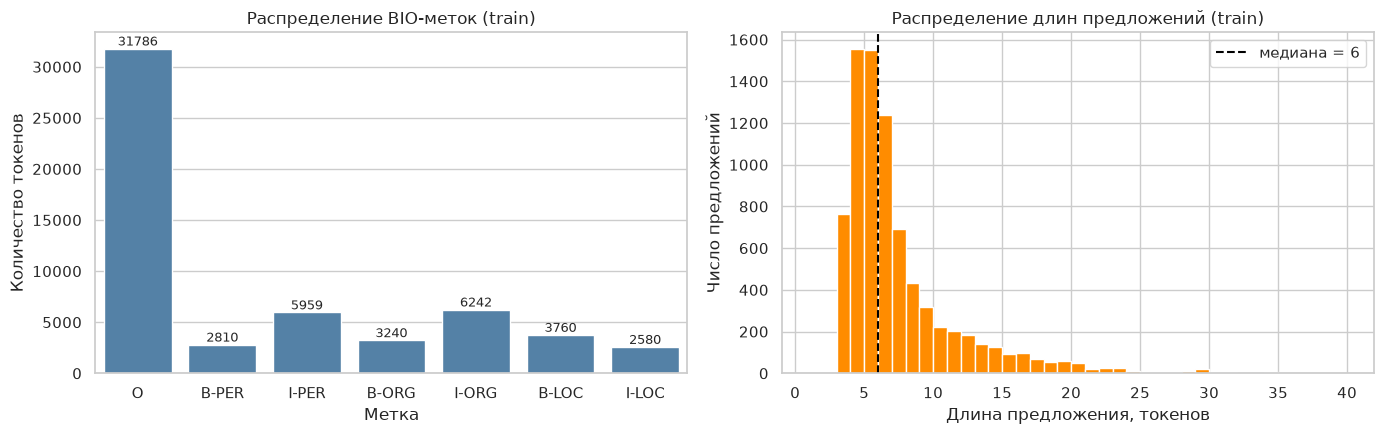

Всего токенов: 56377, доля O: 56.4%
Сущностей по типам: {'PER': 2810, 'ORG': 3240, 'LOC': 3760} | реже всего: PER
Длины предложений: {'count': 8000.0, 'mean': 7.0, 'std': 4.5, 'min': 3.0, '25%': 4.0, '50%': 6.0, '75%': 8.0, 'max': 39.0}
Доля предложений длиннее 30 токенов: 0.2%


In [4]:
# ✍️ ВАШ КОД (задание 1.1)
all_tags = [id2label[t] for row in raw["train"]["ner_tags"] for t in row]
tag_counts = pd.Series(all_tags).value_counts().reindex(label_names, fill_value=0)
sent_lens = pd.Series([len(row) for row in raw["train"]["tokens"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# 1) распределение BIO-меток
sns.barplot(x=tag_counts.index, y=tag_counts.values, color="steelblue", ax=axes[0])
for i, v in enumerate(tag_counts.values):
    axes[0].text(i, v, str(v), ha="center", va="bottom", fontsize=9)
axes[0].set(title="Распределение BIO-меток (train)", xlabel="Метка", ylabel="Количество токенов")

# 2) длины предложений
axes[1].hist(sent_lens, bins=range(1, sent_lens.max() + 2), color="darkorange", edgecolor="white")
axes[1].axvline(sent_lens.median(), color="black", ls="--", label=f"медиана = {sent_lens.median():.0f}")
axes[1].set(title="Распределение длин предложений (train)", xlabel="Длина предложения, токенов", ylabel="Число предложений")
axes[1].legend()
plt.tight_layout()
plt.show()

# 3) доля "O" + сводка по сущностям (число сущностей = число B-меток)
o_share = tag_counts["O"] / tag_counts.sum()
entity_counts = {t: int(tag_counts[f"B-{t}"]) for t in ["PER", "ORG", "LOC"]}
print(f"Всего токенов: {tag_counts.sum()}, доля O: {o_share:.1%}")
print("Сущностей по типам:", entity_counts, "| реже всего:", min(entity_counts, key=entity_counts.get))
print("Длины предложений:", sent_lens.describe().round(1).to_dict())
print(f"Доля предложений длиннее 30 токенов: {(sent_lens > 30).mean():.1%}")

### 💬 Задание 1.2. Выводы (впишите ответ ниже)

Ответьте своими словами, обязательно опираясь на числа, полученные в вашем эксперименте.

1. Какова доля токенов с меткой `O`? Какой тип сущностей (PER, ORG или LOC) встречается реже всего?
2. Что можно сказать о распределении длин предложений? Есть ли большинство коротких или длинных предложений, встречаются ли выбросы?
3. Почему при такой доле токенов `O` token-level accuracy плохо отражает качество модели NER? На какую метрику следует ориентироваться вместо нее и почему?

> *Ваш ответ:*
>
> 1. Метка `O` — самый частый класс: **31 786 из 56 377 токенов, т.е. 56.4 %** обучающей выборки, больше, чем все шесть меток сущностей вместе взятые. Реже всего встречаются сущности **PER: 2 810** (по числу `B-` меток) против 3 240 ORG и 3 760 LOC. При этом у PER и ORG очень много `I-` меток (5 959 `I-PER` и 6 242 `I-ORG`): имена и названия организаций многословные (в среднем ≈ 3.1 и ≈ 2.9 слова на сущность), а локации в основном однословные (2 580 `I-LOC`, ≈ 1.7 слова на сущность). Поэтому по числу *токенов* PER выглядит крупнее LOC, хотя по числу *сущностей* это самый редкий тип.
> 2. Предложения в основном очень короткие: медиана **6 токенов**, среднее 7.0, мода 4, 75 % предложений не длиннее 8 токенов, а 84.6 % — не длиннее 10. Распределение сильно скошено вправо: есть длинный хвост до максимума в **39 токенов**, но длиннее 20 токенов лишь 2 % предложений, а длиннее 30 — 0.2 %, это выбросы. Такая картина объясняется устройством WikiANN: это в основном фрагменты статей Википедии (заголовки, строки списков, подписи вида «X-Фактор ( Украина )»), а не полноценные предложения. До лимита `max_length=128` subword-токенов ни один пример не доходит, так что обрезка на этих данных ничего не теряет.
> 3. При доле `O` 56.4 % модель, которая вообще не находит сущностей и всегда отвечает `O`, уже получит accuracy ≈ 0.56, а модель, которая хорошо размечает `O` и посредственно — сущности, легко наберет больше 0.9. Accuracy усредняет по токенам, поэтому в ней доминирует легкий и неинформативный класс `O`. Ошибка в одном слове длинной сущности почти не меняет accuracy, хотя сущность при этом извлечена неверно. Ориентироваться нужно на **entity-level precision / recall / F1 (seqeval)**: единица оценки — целая сущность, она засчитывается только при точном совпадении границ и типа, а токены `O` сами по себе не дают «бесплатных» очков. Именно это и нужно на практике — извлечь сущность целиком и правильно.

## 2. Токенизация и выравнивание меток (1 балл)

В датасете BIO-метки заданы на уровне слов, тогда как BERT работает с подсловными токенами (subwords). Поэтому перед обучением необходимо перенести метки слов на последовательность подсловных токенов.

В ячейке ниже приведена готовая функция, которая выполняет это выравнивание. Разберитесь, как она работает: в задании 2.1 вам потребуется объяснить ее логику своими словами.

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL)

def align_labels_with_tokens(labels, word_ids):
  """Переносит пословные BIO-метки на subwords."""
  new_labels = []
  prev_word = None
  for word_id in word_ids:
      if word_id is None: # спецтокены [CLS] / [SEP] / паддинг
          new_labels.append(-100)
      elif word_id != prev_word: # первый subword нового слова
          new_labels.append(labels[word_id])
      else: # продолжение того же слова
          new_labels.append(-100)
      prev_word = word_id
  return new_labels

def tokenize_and_align(batch):
  tok = tokenizer(batch["tokens"], truncation=True, is_split_into_words=True, max_length=128)
  tok["labels"] = [align_labels_with_tokens(labels, tok.word_ids(batch_index=i)) for i, labels in enumerate(batch["ner_tags"])]
  return tok

tokenized = raw.map(tokenize_and_align, batched=True, remove_columns=raw["train"].column_names)
data_collator = DataCollatorForTokenClassification(tokenizer)

# Демонстрация на примере
example = raw["train"][1]
enc = tokenizer(example["tokens"], is_split_into_words=True)
aligned = align_labels_with_tokens(example["ner_tags"], enc.word_ids())
print(f'{"токен":<16}{"метка":<10}')
for tok_str, lab in zip(tokenizer.convert_ids_to_tokens(enc["input_ids"]), aligned):
  print(f'{tok_str:<16}{("-100" if lab == -100 else id2label[lab]):<10}')

токен           метка     
[CLS]           -100      
Картина         O         
была            O         
привезен        O         
##а             -100      
из              O         
Флоренции       B-LOC     
в               O         
Мюнхен          B-LOC     
после           O         
почти           O         
двадцати        O         
##летних        -100      
переговоров     O         
и               O         
многих          O         
усилий          O         
вы              O         
##зволи         -100      
##ть            -100      
её              O         
у               O         
прежних         O         
владельцев      O         
.               O         
[SEP]           -100      


### 💬 Задание 2.1. Вопрос на понимание (впишите ответ ниже)

Изучите вывод примера выше и ответьте своими словами (3— 5 предложений):

1. Почему метка сущности присваивается только первому subword слова, а остальные получают значение `-100`?
2. Какую роль играет значение `-100` при обучении модели? Почему его также используют для специальных токенов `[CLS]` и `[SEP]`?
3. Какие проблемы возникли бы, если бы метку слова присваивали всем его subwords?

> *Ваш ответ:* Разметка в датасете задана для слов, поэтому на каждое слово должно приходиться ровно одно предсказание; условно «представителем» слова выбирается его первый subword, а его контекстный эмбеддинг (благодаря self-attention) уже содержит информацию и о продолжениях слова. Значение `-100` — это `ignore_index` у `CrossEntropyLoss`: такие позиции не участвуют ни в функции потерь, ни в градиенте, а в `compute_metrics`/`get_tags` они отбрасываются, поэтому метрики считаются ровно по одному токену на слово. Спецтокены `[CLS]`, `[SEP]` и паддинг не соответствуют никакому слову и не имеют «правильной» метки, поэтому им тоже ставится `-100`, чтобы модель не училась на бессмысленных целях. Если бы метку копировали на все subwords, то (а) длинные, сильно дробящиеся слова (редкие фамилии, транслитерированные названия) получали бы больший вес в loss, и обучение смещалось бы в их сторону; (б) возникли бы проблемы с BIO-схемой: `B-PER` на каждом subword слова «Лермонтов» превратился бы в несколько «начал» сущности, а замена на `I-` требует отдельной логики; (в) метрики считались бы по subwords, а не по словам, и стали бы несопоставимы с пословной разметкой, плюс на инференсе пришлось бы как-то агрегировать противоречивые предсказания для частей одного слова.

## 3. Дообучение модели (2 балла)

Для оценки качества модели в задаче NER используются метрики на уровне сущностей (entity-level), которые вычисляются с помощью библиотеки seqeval. Сущность считается распознанной правильно только в том случае, если модель верно определила и ее границы, и ее тип.

Функция ниже будет вычислять precision, recall и F1 после каждой эпохи обучения. Используйте ее без изменений.

In [6]:
def compute_metrics(eval_pred):
  logits, labels = eval_pred
  preds = np.argmax(logits, axis=-1)

  true_tags, pred_tags = [], []
  for pred_row, label_row in zip(preds, labels):
      tt, pp = [], []
      for p_i, l_i in zip(pred_row, label_row):
          if l_i == -100:
              continue
          tt.append(id2label[l_i])
          pp.append(id2label[p_i])
      true_tags.append(tt)
      pred_tags.append(pp)

  return {
      "precision": seq_precision(true_tags, pred_tags),
      "recall":    seq_recall(true_tags, pred_tags),
      "f1":        seq_f1(true_tags, pred_tags),
  }

### ✍️ Задание 3.1. Дообучите модель

1. Загрузите модель с помощью `AutoModelForTokenClassification.from_pretrained`, указав корректные значения `num_labels`, `id2label` и `label2id`.
2. Настройте `TrainingArguments`: оценка на валидационной выборке после каждой эпохи; 3–4 эпохи обучения; `batch_size=16`; `learning_rate=5e-5`; `seed=RANDOM_STATE`.
3. Создайте `Trainer`, передав обучающую и валидационную выборки, `data_collator`, `compute_metrics` и остальные необходимые параметры, затем запустите обучение с помощью `trainer.train()`.

Во время обучения значение eval_f1 должно постепенно расти.

Сохраните объект `Trainer` в переменную `trainer` —  он понадобится в следующих заданиях.

In [7]:
# ✍️ ВАШ КОД (задание 3.1)
import time

def load_model():
    """Свежая модель rubert-tiny2 со случайно инициализированной головой под наши BIO-метки."""
    return AutoModelForTokenClassification.from_pretrained(
        MODEL, num_labels=len(label_names), id2label=id2label, label2id=label2id
    )

def make_args(**overrides):
    """Общие аргументы обучения; overrides позволяют поменять отдельные параметры (нужно в бонусе)."""
    params = dict(
        output_dir="rubert-tiny2-wikiann-ru",
        eval_strategy="epoch",            # оценка на validation после каждой эпохи
        logging_strategy="epoch",
        save_strategy="no",               # чекпоинты не нужны — экономим диск
        num_train_epochs=4,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=64,
        learning_rate=5e-5,
        weight_decay=0.01,
        seed=RANDOM_STATE,
        fp16=torch.cuda.is_available(),
        report_to="none",
    )
    params.update(overrides)
    return TrainingArguments(**params)

def make_trainer(model, args):
    return Trainer(
        model=model,
        args=args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],
        data_collator=data_collator,
        processing_class=tokenizer,
        compute_metrics=compute_metrics,
    )

model = load_model()
trainer = make_trainer(model, make_args())

start = time.time()
trainer.train()
full_train_time = time.time() - start
print(f"Время обучения: {full_train_time:.1f} c")

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.558280,0.296318,0.702609,0.734751,0.718321
2,0.268330,0.242274,0.756134,0.803772,0.779226
3,0.207410,0.233427,0.771723,0.812600,0.791634
4,0.176522,0.229256,0.778714,0.816212,0.797022


Время обучения: 277.2 c


## 4. Метрики token-level и entity-level (2 балла)

Функция ниже запускает обученную модель на указанном датасете и возвращает две последовательности строковых меток: истинные и предсказанные. Они уже приведены к формату, который можно напрямую использовать для вычисления как entity-level-метрик с помощью seqeval, так и token-level-метрик с помощью sklearn.

Это позволит сравнить оба подхода к оценке качества модели и понять, почему в задаче NER они могут давать заметно разные результаты.

In [8]:
def get_tags(trainer, dataset):
  out = trainer.predict(dataset)
  preds = np.argmax(out.predictions, axis=-1)
  labels = out.label_ids

  true_tags, pred_tags = [], []
  for pred_row, label_row in zip(preds, labels):
      tt, pp = [], []
      for p_i, l_i in zip(pred_row, label_row):
          if l_i == -100:
              continue
          tt.append(id2label[l_i])
          pp.append(id2label[p_i])
      true_tags.append(tt)
      pred_tags.append(pp)
  return true_tags, pred_tags

### ✍️ Задание 4.1. Сравните две оценки на тестовой выборке

1. Получите последовательности истинных и предсказанных меток для тестовой выборки.
2. Выведите entity-level-отчет с помощью `seq_classification_report(true_tags, pred_tags, digits=3)`.
3. Выведите token-level-отчет. Для этого разделите обе последовательности в плоские списки и передайте их в `sk_classification_report(...)`.

In [9]:
# ✍️ ВАШ КОД (задание 4.1)
true_tags, pred_tags = get_tags(trainer, tokenized["test"])

print("=== Entity-level (seqeval) ===")
print(seq_classification_report(true_tags, pred_tags, digits=3))

flat_true = np.array([t for row in true_tags for t in row])
flat_pred = np.array([t for row in pred_tags for t in row])
print("=== Token-level (sklearn) ===")
print(sk_classification_report(flat_true, flat_pred, labels=label_names, digits=3, zero_division=0))

token_acc = (flat_true == flat_pred).mean()
entity_f1 = seq_f1(true_tags, pred_tags)
ent_mask = flat_true != "O"
print(f"token-level accuracy:                    {token_acc:.3f}")
print(f"token-level accuracy без токенов 'O':    {(flat_true[ent_mask] == flat_pred[ent_mask]).mean():.3f}")
print(f"entity-level F1 (micro):                 {entity_f1:.3f}")
print(f"разрыв accuracy − F1:                    {token_acc - entity_f1:.3f}")

=== Entity-level (seqeval) ===
              precision    recall  f1-score   support

         LOC      0.797     0.821     0.809       893
         ORG      0.644     0.705     0.673       836
         PER      0.869     0.913     0.890       698

   micro avg      0.763     0.807     0.785      2427
   macro avg      0.770     0.813     0.791      2427
weighted avg      0.765     0.807     0.785      2427

=== Token-level (sklearn) ===


              precision    recall  f1-score   support

           O      0.966     0.976     0.971      8103
       B-PER      0.921     0.920     0.920       698
       I-PER      0.942     0.956     0.949      1521
       B-ORG      0.801     0.794     0.798       836
       I-ORG      0.869     0.856     0.863      1675
       B-LOC      0.847     0.849     0.848       893
       I-LOC      0.871     0.767     0.816       601

    accuracy                          0.930     14327
   macro avg      0.888     0.874     0.881     14327
weighted avg      0.929     0.930     0.929     14327

token-level accuracy:                    0.930
token-level accuracy без токенов 'O':    0.870
entity-level F1 (micro):                 0.785
разрыв accuracy − F1:                    0.145


### 💬 Задание 4.2 — объясните разрыв (впишите ответ ниже)

Задание 4.2. Объясните различия между двумя оценками

Ответьте своими словами, обязательно используя значения из двух полученных отчетов.

1. Чему равны token-level accuracy и entity-level F1? Насколько они отличаются?
2. Назовите две причины, по которым token-level accuracy оказывается заметно выше.
3. Какую из этих двух оценок вы бы использовали как основную характеристику качества NER-модели и почему?

> *Ваш ответ:*
>
> 1. На тесте **token-level accuracy = 0.930**, а **entity-level micro-F1 = 0.785** (precision 0.763, recall 0.807) — разрыв **14.5 п.п.** Если посчитать accuracy только по токенам, у которых истинная метка не `O`, она падает до **0.870**: значит, заметную часть «хорошей» accuracy дают токены `O`.
> 2. Две причины:
>    - **Доминирование класса `O`.** В тесте 8 103 из 14 327 токенов (56.6 %) — `O`, и модель размечает их почти безошибочно (token-level F1 по `O` = **0.971**). Эти легкие токены раздувают accuracy, а в entity-level метрике они вообще не являются объектами оценки.
>    - **Строгость entity-level оценки.** Сущность засчитывается только при точном совпадении всех границ и типа, а одна ошибка в длинной сущности обнуляет ее целиком и считается дважды: как FN (истинная сущность не найдена) и как FP (найдена «неправильная»). Хорошо видно на ORG: токен-уровневые F1 у `B-ORG` / `I-ORG` = 0.798 / 0.863, а entity-level F1 у ORG всего **0.673** — у многословных названий организаций «почти правильные» предсказания по токенам превращаются в неправильные сущности. У однословных и шаблонных PER разрыв меньше (0.920 / 0.949 по токенам против 0.890 по сущностям).
> 3. Основная метрика — **entity-level F1** (вместе с precision/recall по типам из seqeval). Она отражает реальную пользу модели: на выходе NER нужны целые сущности с правильным типом, а обрезанная или неверно типизированная сущность для поиска, базы знаний или аналитики практически бесполезна. Token-level отчет полезен как вспомогательная диагностика — например, по нему видно, что слабее всего модель находит продолжения локаций (recall `I-LOC` = 0.767).

## 5. Анализ ошибок по сущностям (2 балла)

Функция `get_tags` возвращает метки на уровне слов в том же порядке, в котором слова представлены в `raw["test"]["tokens"]`. Благодаря этому каждому слову соответствует ровно одна истинная и одна предсказанная метка, поэтому слова и теги можно сопоставлять напрямую при анализе ошибок модели.

### ✍️ Задание 5.1. Найдите и выведите ошибки модели

Просмотрите предложения тестовой выборки и найдите те, в которых предсказанные метки (`pred_tags`) отличаются от истинных (`true_tags`).

Выведите не менее трех таких предложений. Для каждого покажите:

- слово, в котором обнаружено расхождение;
- истинную метку;
- предсказанную метку;
- несколько соседних слов для контекста (до и после ошибки).

In [10]:
# ✍️ ВАШ КОД (задание 5.1)
from collections import Counter
from seqeval.metrics.sequence_labeling import get_entities

ERROR_KINDS = ["нарушение границ", "путаница типа", "границы + тип", "пропуск сущности", "ложное срабатывание"]

def overlap(a, b):
    """Пересекаются ли спаны (type, start, end), end включительно."""
    return a[1] <= b[2] and b[1] <= a[2]

def classify_errors(true_seq, pred_seq):
    """Сопоставляет истинные и предсказанные сущности, возвращает список (тип_ошибки, true_span, pred_span)."""
    true_ents, pred_ents = set(get_entities(true_seq)), set(get_entities(pred_seq))
    wrong_true, wrong_pred = true_ents - pred_ents, pred_ents - true_ents
    errors = []
    for t in wrong_true:
        cands = [p for p in wrong_pred if overlap(t, p)]
        if not cands:
            errors.append(("пропуск сущности", t, None))
        for p in cands:
            if t[1:] == p[1:]:
                kind = "путаница типа"
            elif t[0] == p[0]:
                kind = "нарушение границ"
            else:
                kind = "границы + тип"
            errors.append((kind, t, p))
    for p in wrong_pred:
        if not any(overlap(p, t) for t in true_ents):
            errors.append(("ложное срабатывание", None, p))
    return errors

def show_error(idx, kind, t, p, window=3):
    """Печатает ошибку: слова с истинной и предсказанной меткой + контекст из window слов слева и справа."""
    tt, pp = true_tags[idx], pred_tags[idx]
    words = raw["test"][idx]["tokens"][: len(tt)]  # на случай обрезки до max_length
    spans = [s for s in (t, p) if s]
    lo = max(0, min(s[1] for s in spans) - window)
    hi = min(len(words), max(s[2] for s in spans) + window + 1)
    print(f"[{kind}] предложение #{idx}: истинная = {t[0] if t else '—'}, предсказанная = {p[0] if p else '—'}")
    print(f"   контекст: {' '.join(words[lo:hi])}")
    for i in range(lo, hi):
        mark = "   <-- расхождение" if tt[i] != pp[i] else ""
        print(f"      {words[i]:<22} true={tt[i]:<7} pred={pp[i]:<7}{mark}")
    print()

# Собираем ошибки по всему тесту
all_errors = [(i, *e) for i, (tt, pp) in enumerate(zip(true_tags, pred_tags)) for e in classify_errors(tt, pp)]
print(f"Предложений с ошибками: {len({e[0] for e in all_errors})} из {len(true_tags)}, всего ошибок по сущностям: {len(all_errors)}\n")
display(pd.Series([e[1] for e in all_errors]).value_counts().reindex(ERROR_KINDS, fill_value=0).to_frame("число ошибок"))

# Какие типы чаще всего путаются между собой (только ошибки с совпадающими границами)
type_conf = Counter(f"{t[0]} → {p[0]}" for _, k, t, p in all_errors if k == "путаница типа")
print("Путаница типов (истинный → предсказанный):", dict(type_conf.most_common()), "\n")

# По два примера каждого типа ошибки (из разных предложений, без повторов)
shown = set()
for kind in ERROR_KINDS:
    examples = [e for e in all_errors if e[1] == kind and e[0] not in shown][:2]
    for idx, k, t, p in examples:
        shown.add(idx)
        show_error(idx, k, t, p)

Предложений с ошибками: 471 из 2000, всего ошибок по сущностям: 688



,число ошибок
нарушение границ,240
путаница типа,170
границы + тип,113
пропуск сущности,57
ложное срабатывание,108


Путаница типов (истинный → предсказанный): {'LOC → ORG': 57, 'ORG → LOC': 56, 'ORG → PER': 20, 'PER → ORG': 14, 'LOC → PER': 13, 'PER → LOC': 10} 

[нарушение границ] предложение #0: истинная = ORG, предсказанная = ORG
   контекст: перенаправление Мост Богдана Хмельницкого
      перенаправление        true=O       pred=O      
      Мост                   true=B-ORG   pred=B-PER     <-- расхождение
      Богдана                true=I-ORG   pred=I-ORG  
      Хмельницкого           true=I-ORG   pred=I-PER     <-- расхождение

[нарушение границ] предложение #2: истинная = ORG, предсказанная = ORG
   контекст: Лёгкая атлетика ( мужчины , бег на 110 метров с барьерами )
      Лёгкая                 true=B-ORG   pred=B-ORG  
      атлетика               true=I-ORG   pred=I-ORG  
      (                      true=O       pred=I-ORG     <-- расхождение
      мужчины                true=B-ORG   pred=I-ORG     <-- расхождение
      ,                      true=I-ORG   pred=O         <-- расхожде

### 💬 Задание 5.2. Проанализируйте ошибки модели (впишите ответ ниже)

Опираясь на найденные вами примеры, ответьте на вопросы:

1. Отнесите найденные ошибки как минимум к двум разным типам: нарушение границ сущности, путаница типа между PER, ORG и LOC, пропуск сущности или ложное срабатывание.
2. Для каждого типа приведите конкретный пример из своего вывода.
Выберите один из наиболее часто встречающихся типов ошибок и объясните, почему он возникает. Объяснение должно быть связано с особенностями текста или данных (например, неоднозначностью контекста, похожими шаблонами, редкостью примеров и т.п.).

> *Ваш ответ:*
>
> 1. Код классифицировал все **688** ошибок на тесте (они есть в **471** из 2 000 предложений):
>
>    | тип ошибки | число | доля |
>    |---|---|---|
>    | нарушение границ (тип верный) | 240 | 35 % |
>    | путаница типа (границы верные) | 170 | 25 % |
>    | границы + тип одновременно | 113 | 16 % |
>    | ложное срабатывание | 108 | 16 % |
>    | пропуск сущности | 57 | 8 % |
>
>    Среди ошибок типа при верных границах доминирует пара **LOC ↔ ORG**: 57 (LOC → ORG) + 56 (ORG → LOC) = 113 из 170 (66 %). Остальные пары встречаются заметно реже (ORG → PER 20, PER → ORG 14, LOC → PER 13, PER → LOC 10).
> 2. Примеры из вывода выше:
>    - **Нарушение границ:** «Лёгкая атлетика ( мужчины , бег на 110 метров с барьерами )» — модель продлила ORG через скобку на слово «мужчины» и остановилась, хотя в разметке это две отдельные ORG-сущности. Еще пример — «Мост Богдана Хмельницкого» (ORG): модель разбила название на `B-PER I-ORG I-PER`, т.е. перепутала и тип, и границы части сущности, потому что внутри названия стоит имя человека.
>    - **Путаница типа:** «пятый президент Либерии» — `Либерии` (LOC) предсказано как PER, видимо из-за соседства со словом «президент».
>    - **Границы + тип:** «Кривбасс ( Кривой Рог )» и «X-Фактор ( Украина )» — в разметке это одна ORG вместе с городом/страной в скобках, а модель выделила город как отдельную LOC.
>    - **Пропуск и ложное срабатывание:** «В решающей серии «Питтсбург» снова встречается…» — модель нашла клуб «Питтсбург» (ORG), которого нет в разметке (формально ложное срабатывание), и пропустила «решающей серии», размеченное как PER (формально пропуск). Настоящие ложные срабатывания тоже есть: в «СМ — «Спартак» ( Москва )» модель приняла «СМ —» за отдельную ORG, а в почтовом адресе «6800 Фельдкирх , Райхштрасе , 151» разметила улицу как LOC.
>
>    Часть этих «ошибок» на самом деле **ошибки разметки**, а не модели: «Межнациональная хоккейная лига» размечена как PER (модель ответила ORG — правильно), «решающей серии» — PER, «испанского» в «картина испанского художника» — LOC, «Фельдкирх» — ORG. WikiANN размечен автоматически (по ссылкам Википедии), поэтому шум разметки занижает измеренное качество.
>
> **Почему самая частая ошибка — границы (и путаница ORG ↔ LOC).** В WikiANN очень много шаблона «Название ( Город )»: «Спартак ( Москва )», «Кривбасс ( Кривой Рог )», «X-Фактор ( Украина )». Иногда уточнение в скобках входит в сущность ORG, иногда нет, а сам город в скобках — типичная LOC. Шаблон один и тот же, а правильный ответ зависит от того, на какую статью вела ссылка в Википедии, и по тексту фрагмента этого не понять. Модель видит очень короткий контекст (медиана 6 слов) и не может разрешить неоднозначность, поэтому ошибается либо в границе (включать ли скобку), либо в типе (клуб, названный по городу, — ORG или LOC). Из-за этого ORG — самый «неудобный» тип: многословные названия со встроенными топонимами и именами людей («Мост Богдана Хмельницкого»), и отсюда же его самый низкий entity-level F1 (0.673).

## 6. Вывод (2 балла)

### 💬 Задание 6.1. Вывод (впишите ответ ниже)

Напишите вывод объемом 5—8 предложений, опираясь на результаты своего эксперимента.

В выводе ответьте на следующие вопросы:

1. Какое значение entity-level F1 удалось получить? Какие типы сущностей (PER, ORG, LOC) распознаются лучше, а какие хуже? Подкрепите ответ результатами и предложите возможное объяснение.
2. Для каких задач такая модель уже может быть полезна? В каких сценариях ее качества пока недостаточно?
3. Какие ограничения были у проведенного эксперимента (например, шум разметки, размер обучающей выборки, размер модели, ограничение длины последовательности)? Назовите одно конкретное улучшение, которое, по вашему мнению, может повысить качество модели.

> *Ваш ответ:* Дообученная за 4 эпохи `rubert-tiny2` на 8 000 примерах WikiANN-ru дает на тесте **entity-level micro-F1 = 0.785** (P = 0.763, R = 0.807; на валидации — 0.797 после 4-й эпохи, рост 0.718 → 0.779 → 0.792 → 0.797), при token-level accuracy 0.930, что еще раз показывает, насколько accuracy завышает качество. Лучше всего распознаются **PER (F1 = 0.890)**: у имен людей устойчивые шаблоны (имя + фамилия, инициалы, заглавные буквы), и они редко неоднозначны. **LOC (0.809)** немного хуже: топонимы короткие и частые, но часто входят в названия организаций или сами служат названиями клубов. Хуже всего — **ORG (0.673)**: это длинные и разнородные сущности с вложенными именами и топонимами, на них приходится основная масса ошибок границ и две трети ошибок типа (113 из 170 — путаница LOC ↔ ORG). Такая модель уже полезна там, где допустим шум и важен охват: предразметка текстов для аннотаторов, подсветка персон и мест в поиске, грубая аналитика упоминаний — особенно для PER. Для задач, где нужна высокая точность (автоматическое наполнение баз знаний, юридические и финансовые документы, связывание сущностей), качества, особенно по ORG, пока недостаточно. Ограничения эксперимента: обучение на 8 000 из 20 000 примеров, один запуск с одним seed и без подбора гиперпараметров, очень маленькая модель (29 млн параметров). Кроме того, разметка WikiANN автоматическая и шумная (в анализе ошибок нашлись явные ошибки разметки), а сами данные — короткие фрагменты Википедии (медиана 6 слов), так что качество на обычных текстах (новости, соцсети) может оказаться заметно ниже. Ограничение `max_length=128` на этих данных ничего не обрезало. Конкретное улучшение — обучиться на **полном train (20 000 примеров)** с подбором learning rate и числа эпох по валидации (кривая валидационного F1 еще не вышла на плато); следующий шаг — более крупный энкодер (`ai-forever/ruBert-base`, `xlm-roberta-base`) и/или CRF-слой поверх, чтобы предсказания соблюдали BIO-согласованность и реже ошибались на границах.

## Бонусное задание

> Бонусная часть не является обязательной к выполнению и не влияет на оценку за домашнее задание. Выполнив это задание, вы получите развернутую обратную связь в свободной форме. Здесь нет строгих критериев выполнения.

В основном задании вы дообучали всю модель: обновлялись веса и энкодера BERT, и классификационной головы. Однако существует более дешевый режим обучения —  заморозить энкодер и обучать только выходную голову поверх фиксированных контекстных представлений, которые вычисляет BERT.

Такой подход позволяет значительно сократить число обучаемых параметров и ускорить обучение, но обычно приводит к некоторой потере качества.

Проверьте это на практике: сравните полное дообучение модели с обучением только классификационной головы и оцените, насколько меняются качество и время обучения.

### ✍️ Задание Б1. Обучите модель с замороженным энкодером

1. Загрузите новую модель с помощью `AutoModelForTokenClassification.from_pretrained`, используя те же параметры, что и в блоке 3.
2. Заморозьте энкодер BERT: пройдите по `model_frozen.base_model.parameters()` и установите `requires_grad=False` для всех его параметров. Классификационная голова (`classifier`) должна остаться обучаемой.
3. Создайте новый объект `Trainer` (можно использовать те же `TrainingArguments`), обучите модель и сравните ее с моделью из основного задания: значение entity-level F1 на тестовой выборке и время обучения.

> *Подсказка.* Время обучения удобно измерить с помощью `time.time()` до и после вызова `trainer.train()`.

In [11]:
# ✍️ ВАШ КОД (задание Б1)
def count_params(m):
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return trainable, sum(p.numel() for p in m.parameters())

def train_frozen(**arg_overrides):
    """Обучает только классификационную голову поверх замороженного энкодера."""
    model_frozen = load_model()
    for p in model_frozen.base_model.parameters():
        p.requires_grad = False
    trainer_frozen = make_trainer(model_frozen, make_args(**arg_overrides))
    start = time.time()
    trainer_frozen.train()
    elapsed = time.time() - start
    f_true, f_pred = get_tags(trainer_frozen, tokenized["test"])
    return model_frozen, elapsed, seq_f1(f_true, f_pred), (f_true, f_pred)

# 1) те же гиперпараметры, что и в основном задании (lr=5e-5)
model_frozen, frozen_time, frozen_f1, frozen_tags = train_frozen()
# 2) голова — это один линейный слой, ему нужен больший шаг: lr=1e-3 для честного сравнения
_, frozen_time_hi, frozen_f1_hi, frozen_tags_hi = train_frozen(learning_rate=1e-3)

full_trainable, total = count_params(model)
frozen_trainable, _ = count_params(model_frozen)
comparison = pd.DataFrame(
    {
        "entity F1 (test)": [entity_f1, frozen_f1, frozen_f1_hi],
        "время обучения, c": [full_train_time, frozen_time, frozen_time_hi],
        "обучаемых параметров": [full_trainable, frozen_trainable, frozen_trainable],
    },
    index=["полное дообучение (lr=5e-5)", "замороженный энкодер (lr=5e-5)", "замороженный энкодер (lr=1e-3)"],
)
print(f"Всего параметров: {total:,}; обучаемых при заморозке: {frozen_trainable:,} ({frozen_trainable / total:.3%})")
display(comparison.round(3))
print("Замороженный энкодер, lr=1e-3 — entity-level отчет:")
print(seq_classification_report(*frozen_tags_hi, digits=3, zero_division=0))

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,1.470671,1.154634,0.100830,0.034109,0.050975
2,1.084193,0.969969,0.293206,0.197432,0.235971
3,0.971404,0.895655,0.354687,0.302167,0.326327
4,0.927606,0.874936,0.366019,0.325040,0.344315


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.699126,0.493052,0.475625,0.595104,0.528699
2,0.545811,0.462896,0.490681,0.612761,0.544968
3,0.529378,0.451541,0.500162,0.618780,0.553184
4,0.522671,0.447583,0.497730,0.615971,0.550574


Всего параметров: 29,098,303; обучаемых при заморозке: 2,191 (0.008%)


,entity F1 (test),"время обучения, c",обучаемых параметров
полное дообучение (lr=5e-5),0.785,277.210,29098303
замороженный энкодер (lr=5e-5),0.327,92.562,2191
замороженный энкодер (lr=1e-3),0.532,93.041,2191


Замороженный энкодер, lr=1e-3 — entity-level отчет:
              precision    recall  f1-score   support

         LOC      0.505     0.654     0.570       893
         ORG      0.310     0.395     0.347       836
         PER      0.616     0.817     0.702       698

   micro avg      0.471     0.611     0.532      2427
   macro avg      0.477     0.622     0.540      2427
weighted avg      0.470     0.611     0.531      2427



### 💬 Задание Б2. Рефлексия (впишите ответ ниже)

Ответьте своими словами, опираясь на результаты своего эксперимента.

1. Как изменились entity-level F1 и время обучения после заморозки энкодера? Приведите оба значения.
2. Почему заморозка энкодера обычно сильнее влияет на качество в задаче NER, чем в задаче классификации всего текста?
3. В каких случаях вы бы все же предпочли обучать только классификационную голову?

> *Ваш ответ:*
>
> 1. При заморозке энкодера обучается только линейная голова — **2 191** параметр из 29 098 303 (**0.008 %**). Результаты на тесте (обучение на CPU):
>
>    | режим | entity F1 (test) | время обучения |
>    |---|---|---|
>    | полное дообучение, lr = 5e-5 | **0.785** | 277 с |
>    | замороженный энкодер, lr = 5e-5 | **0.327** | 93 с |
>    | замороженный энкодер, lr = 1e-3 | **0.532** | 93 с |
>
>    С теми же гиперпараметрами (lr = 5e-5) голова за 4 эпохи почти не успевает обучиться: F1 падает **с 0.785 до 0.327**, а валидационный loss все еще 0.87 против 0.23 у полной модели. С более подходящим для одного линейного слоя шагом (lr = 1e-3) получается **0.532**, но это все равно на 25 п.п. хуже полного дообучения. Сильнее всего страдает ORG (F1 0.347 против 0.673), меньше всего — PER (0.702 против 0.890). Время обучения сократилось примерно **в 3 раза (277 с → 93 с)**: не нужны обратный проход через энкодер и шаг оптимизатора по его весам, но прямой проход через всю модель на каждом батче остается, поэтому ускорение несравнимо с тем, во сколько раз уменьшилось число обучаемых параметров.
> 2. В классификации текста голове нужен один вектор на весь текст, и признаки вроде темы или тональности уже неплохо закодированы в предобученных представлениях. В NER решение принимается для **каждого** токена, и нужны очень специфичные признаки: где начинается и где заканчивается сущность (`B-` vs `I-`), какой у слова тип в данном контексте. Предобученный MLM-энкодер таким признакам явно не учили, а линейная голова не может их «достроить» — она только линейно разделяет готовые эмбеддинги. Кроме того, метка ставится только на первый subword, и без дообучения энкодер не учится собирать в нем информацию обо всем слове. Наконец, entity-level метрика строгая: небольшая потеря качества на токенах превращается в большую потерю на целых сущностях. Это видно по ORG, где нужно правильно определить сразу несколько границ.
> 3. Обучать только голову имеет смысл, когда: размеченных данных очень мало (сотни примеров) и полное дообучение быстро переобучается; ресурсы сильно ограничены (нет GPU, обучение на устройстве, нужно ускорение в 3 раза, а потеря качества допустима); один общий замороженный энкодер обслуживает много задач и голов сразу (эмбеддинги можно посчитать один раз и закэшировать, тогда обучение головы еще дешевле); нужен быстрый baseline или probing — проверка, насколько информативны сами представления. Хороший компромисс между этими режимами — разморозить несколько верхних слоев или использовать адаптеры/LoRA.